In [1]:
from IPython import get_ipython
from IPython.display import display
from google.colab import drive


ModuleNotFoundError: No module named 'google'

In [3]:
import pandas as pd

file_path = '/content/Diabetes_Prediction_Dataset (1).csv' # Corrected file extension
df = pd.read_csv(file_path)
df.head()

ModuleNotFoundError: No module named 'pandas'

In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import shapiro
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler

# *Diabetes Prediction System*

In [36]:
df2 = df.copy()
df2.shape

(70692, 22)

# **Graphical Representation of Data in the Dataset**

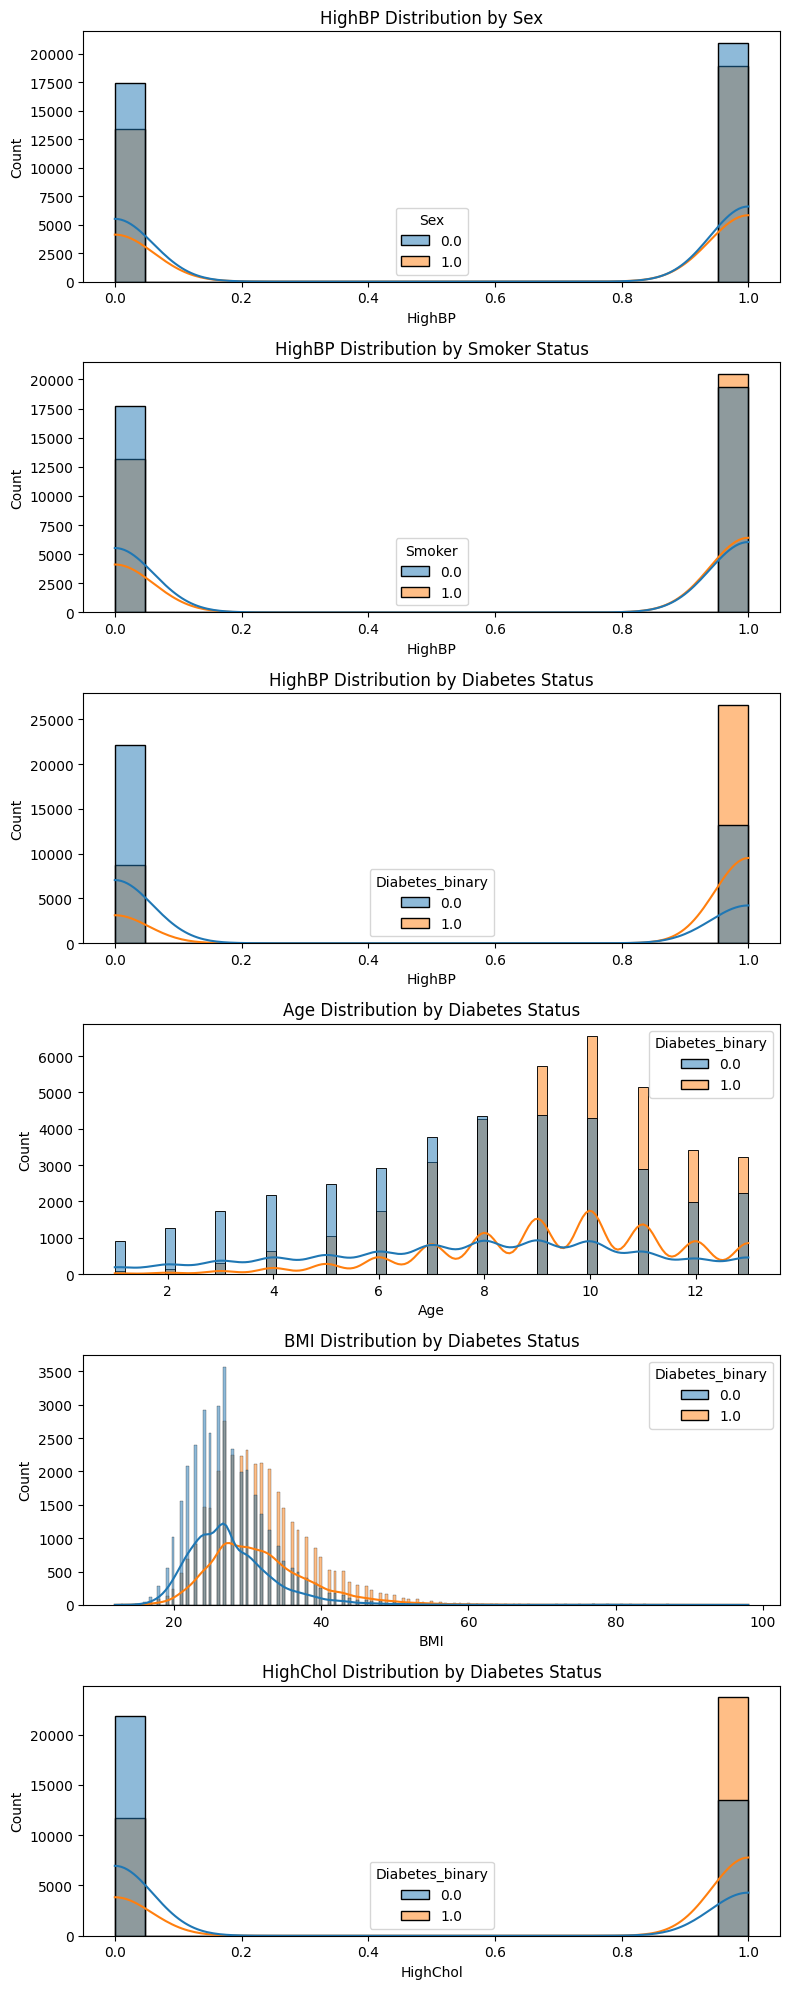

In [37]:

plt.figure(figsize=(8, 20))  # Increased height for 6 subplots

# 6 rows, 1 column layout
plt.subplot(6, 1, 1)
sns.histplot(df2, x='HighBP', hue='Sex', kde=True)
plt.title('HighBP Distribution by Sex')

plt.subplot(6, 1, 2)
sns.histplot(df2, x='HighBP', hue='Smoker', kde=True)
plt.title('HighBP Distribution by Smoker Status')

plt.subplot(6, 1, 3)
sns.histplot(df2, x='HighBP', hue='Diabetes_binary', kde=True)
plt.title('HighBP Distribution by Diabetes Status')

plt.subplot(6, 1, 4)
sns.histplot(df2, x='Age', hue='Diabetes_binary', kde=True)
plt.title('Age Distribution by Diabetes Status')

plt.subplot(6, 1, 5)
sns.histplot(df2, x='BMI', hue='Diabetes_binary', kde=True)
plt.title('BMI Distribution by Diabetes Status')

plt.subplot(6, 1, 6)
sns.histplot(df2, x='HighChol', hue='Diabetes_binary', kde=True)
plt.title('HighChol Distribution by Diabetes Status')

plt.tight_layout()
plt.show()


# Exploratory Data Analysis (EDA) Preprossesing:

# Logistic Regression

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70692 entries, 0 to 70691
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Diabetes_binary       70692 non-null  float64
 1   HighBP                70692 non-null  float64
 2   HighChol              70692 non-null  float64
 3   CholCheck             70692 non-null  float64
 4   BMI                   70692 non-null  float64
 5   Smoker                70692 non-null  float64
 6   Stroke                70692 non-null  float64
 7   HeartDiseaseorAttack  70692 non-null  float64
 8   PhysActivity          70692 non-null  float64
 9   Fruits                70692 non-null  float64
 10  Veggies               70692 non-null  float64
 11  HvyAlcoholConsump     70692 non-null  float64
 12  AnyHealthcare         70692 non-null  float64
 13  NoDocbcCost           70692 non-null  float64
 14  GenHlth               70692 non-null  float64
 15  MentH

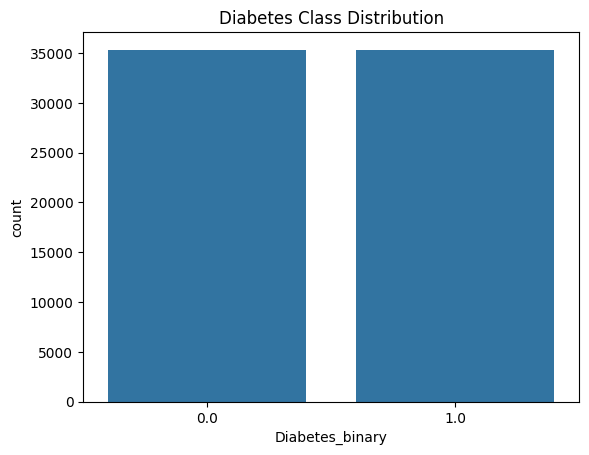

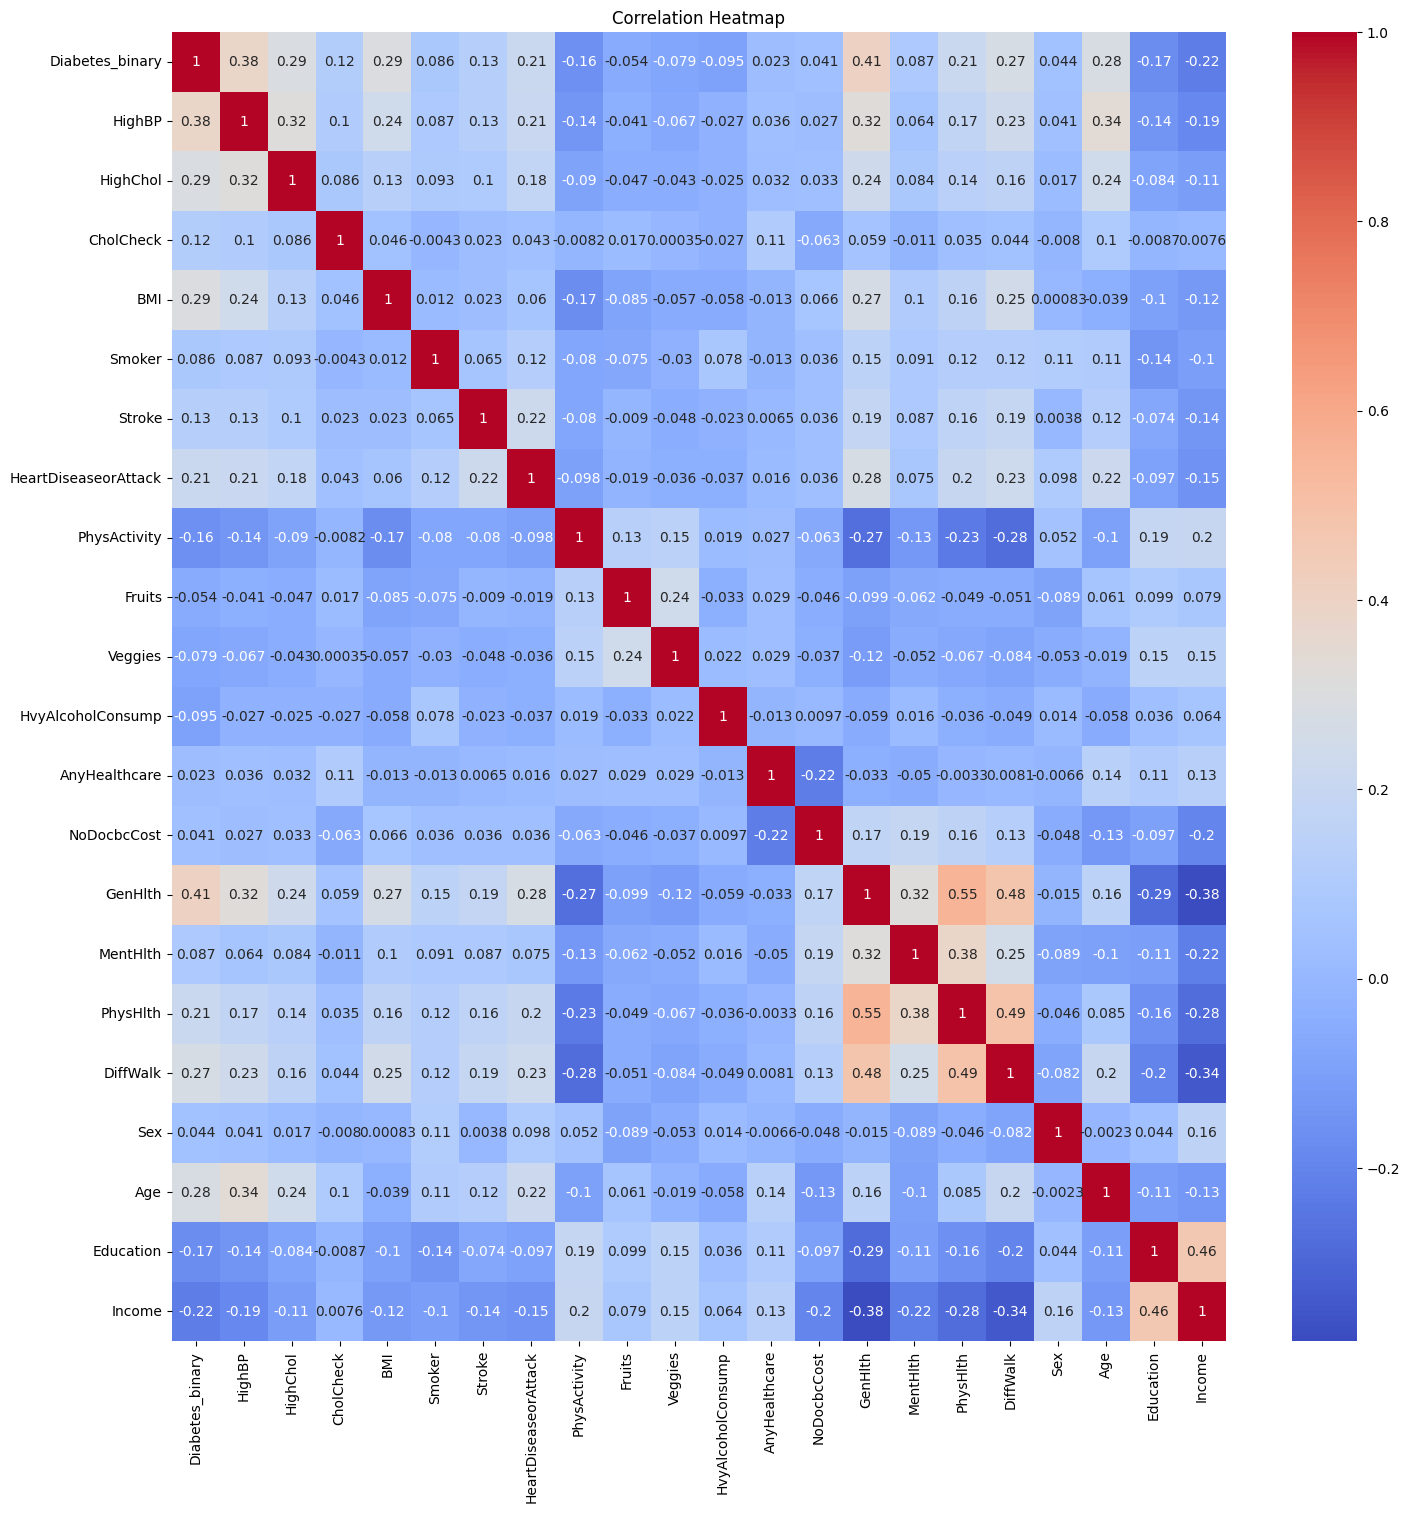

In [38]:

# 1. Basic Info
print("Dataset Info:")
df2.info()
print("\n")

# 2. Shape and First 5 Rows
print("Shape of Dataset:", df.shape)
print(df2.head(), "\n")

# 3. Null Values
print("Missing Values:")
print(df2.isnull().sum(), "\n")

# 4. Summary Stats (Numerical)
print("Summary Statistics:")
print(df2.describe(), "\n")

# 5. Unique Values in Key Categorical Columns
cat_cols = ['Sex', 'Smoker', 'Diabetes_binary']
for col in cat_cols:
    print(f"Unique values in '{col}':", df[col].unique())

# 6. Target Distribution (Diabetes)
sns.countplot(data=df, x='Diabetes_binary')
plt.title("Diabetes Class Distribution")
plt.show()

# 7. Correlation Heatmap
plt.figure(figsize=(17, 17))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

Accuracy: 0.7484263384963576

Classification Report:
               precision    recall  f1-score   support

         0.0       0.76      0.73      0.74      7090
         1.0       0.74      0.77      0.75      7049

    accuracy                           0.75     14139
   macro avg       0.75      0.75      0.75     14139
weighted avg       0.75      0.75      0.75     14139



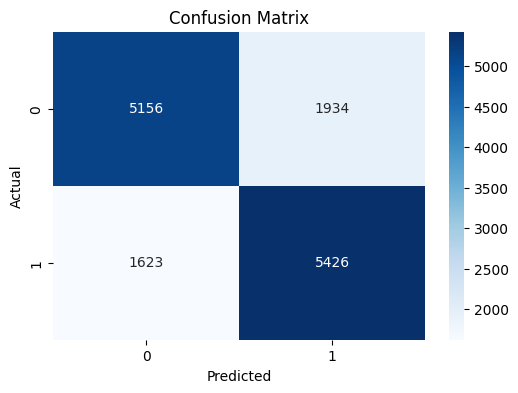

In [39]:
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
df2 = df.copy()


# Define features and target
X = df2.drop('Diabetes_binary', axis=1)
y = df2['Diabetes_binary']

# Scaling (for ANN)
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Split once
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


# Train logistic regression
logistic_model = LogisticRegression(max_iter=1000) # Increased max_iter for convergence
logistic_model.fit(X_train, y_train)

# Predict
y_pred_lr = logistic_model.predict(X_test)

# Evaluate
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("\nClassification Report:\n", classification_report(y_test, y_pred_lr))

# Confusion matrix plot
cm = confusion_matrix(y_test, y_pred_lr)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# Random Forest

Accuracy: 0.7364735837046468

Classification Report:
               precision    recall  f1-score   support

         0.0       0.76      0.69      0.73      7090
         1.0       0.72      0.78      0.75      7049

    accuracy                           0.74     14139
   macro avg       0.74      0.74      0.74     14139
weighted avg       0.74      0.74      0.74     14139



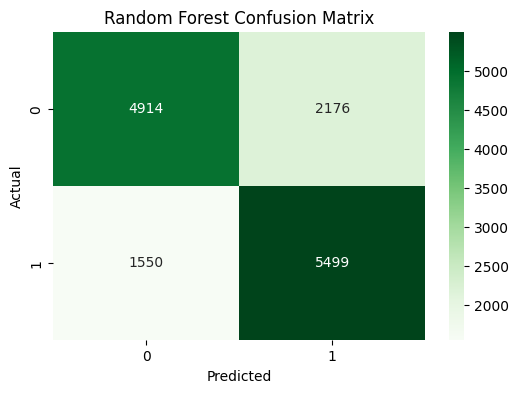

In [40]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import LabelEncoder


# Encode categorical columns (note: 'Sex' and 'Smoker' are already 0/1 in this dataset, so LabelEncoder isn't strictly needed for them, but won't hurt)
le = LabelEncoder()
# If 'Sex' and 'Smoker' were strings, these lines would be crucial. As they are floats, they won't change much.
# df2['Sex'] = le.fit_transform(df2['Sex']) # Not necessary if already 0.0/1.0 floats
# df2['Smoker'] = le.fit_transform(df2['Smoker']) # Not necessary if already 0.0/1.0 floats

# Features and target
X = df2.drop('Diabetes_binary', axis=1) # Corrected target column name
y = df2['Diabetes_binary'] # Corrected target column name



# Initialize and train Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Predict
y_pred_rf = rf_model.predict(X_test)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))

# Confusion matrix plot
cm = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Random Forest Confusion Matrix')
plt.show()


# Decision Tree:

Accuracy: 0.6494801612561002

Classification Report:
               precision    recall  f1-score   support

         0.0       0.65      0.65      0.65      7090
         1.0       0.65      0.65      0.65      7049

    accuracy                           0.65     14139
   macro avg       0.65      0.65      0.65     14139
weighted avg       0.65      0.65      0.65     14139



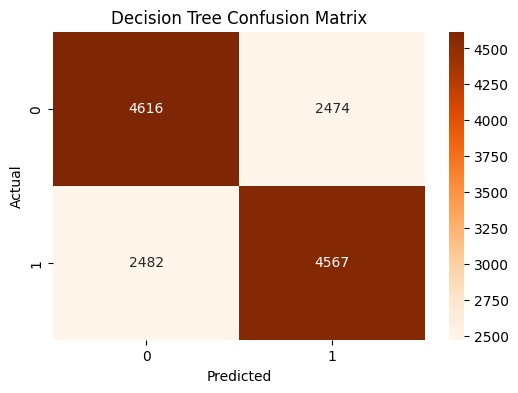

In [41]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import LabelEncoder

# Encode categorical columns (not strictly needed for Sex and Smoker as they are already 0.0/1.0 floats)
le = LabelEncoder()
# df2['Sex'] = le.fit_transform(df2['Sex']) # Example if 'Sex' was a string, but it's already numeric
# df2['Smoker'] = le.fit_transform(df2['Smoker']) # Example if 'Smoker' was a string, but it's already numeric

# Features and target
X = df2.drop('Diabetes_binary', axis=1) # Corrected target column name
y = df2['Diabetes_binary'] # Corrected target column name


# Initialize and train Decision Tree
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

# Predict
y_pred_dt = dt_model.predict(X_test)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print("\nClassification Report:\n", classification_report(y_test, y_pred_dt))

# Confusion matrix plot
cm = confusion_matrix(y_test, y_pred_dt)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Decision Tree Confusion Matrix')
plt.show()

# Artificial Neural Network:

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


2828/2828 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.7440 - loss: 0.5172 - val_accuracy: 0.7490 - val_loss: 0.5078
Epoch 2/50
2828/2828 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.7535 - loss: 0.5041 - val_accuracy: 0.7488 - val_loss: 0.5068
Epoch 3/50
2828/2828 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.7546 - loss: 0.5019 - val_accuracy: 0.7515 - val_loss: 0.5039
Epoch 4/50
2828/2828 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.7558 - loss: 0.4998 - val_accuracy: 0.7527 - val_loss: 0.5038
Epoch 5/50
2828/2828 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.7564 - loss: 0.4988 - val_accuracy: 0.7537 - val_loss: 0.5038
Epoch 6/50
2828/2828 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.7570 - loss: 0.4979 - val_accuracy: 0.7506 - val_loss: 0.5042
Epoch 7/50
2828/2828 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.7590 - loss: 0.4971 - val_accuracy: 0.7502 - val_loss: 0.5033
Epoch 8/50
2828/2828 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.7578 - loss: 0.4960 - val_accurac

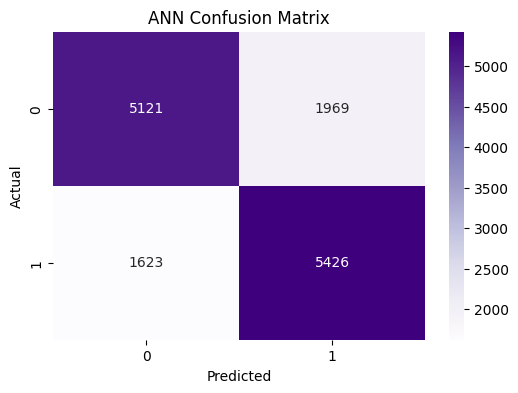

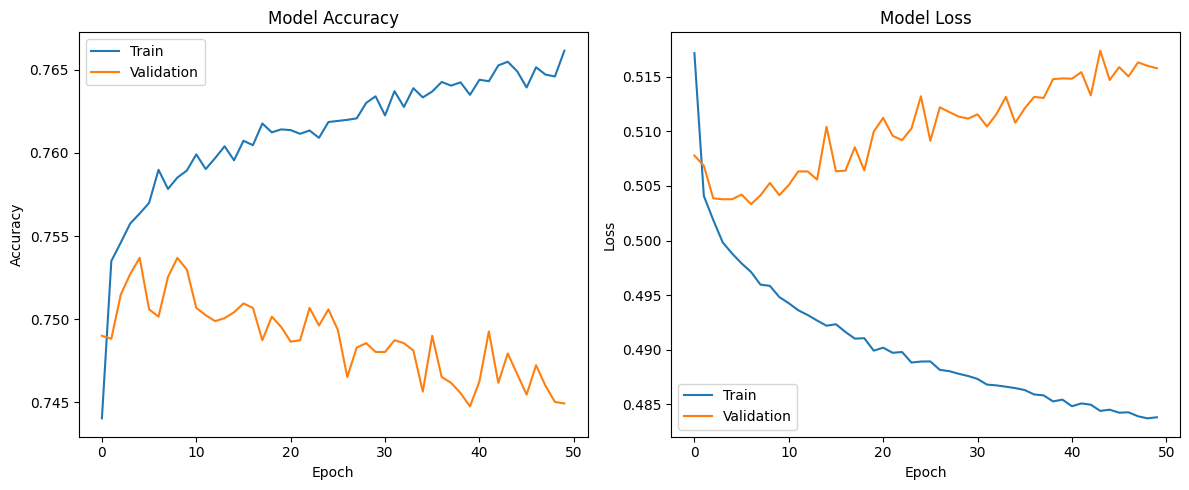

In [50]:

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns



scaler = StandardScaler()
X_scaled = scaler.fit_transform(df2.drop('Diabetes_binary', axis=1))

y = df2['Diabetes_binary'].values

# Train-test split (if not already done)
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)


model = Sequential([
    Dense(32, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)



history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=16,
    validation_split=0.2,
    verbose=1
)



loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"\n ANN Test Accuracy: {accuracy:.4f}")



y_pred_prob = model.predict(X_test)
y_pred_ann = (y_pred_prob > 0.5).astype(int).flatten()


print("\n Classification Report:\n")
print(classification_report(y_test, y_pred_ann))


cm = confusion_matrix(y_test, y_pred_ann)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('ANN Confusion Matrix')
plt.show()



plt.figure(figsize=(12,5))

# Accuracy graph
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train','Validation'])

# Loss graph
plt.subplot(1,2,2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train','Validation'])

plt.tight_layout()
plt.show()

# Data Prediction

In [44]:
import pandas as pd

feature_columns = df2.drop('Diabetes_binary', axis=1).columns.tolist()

input_data_values = df.iloc[0].drop('Diabetes_binary').values.tolist()

new_data_df = pd.DataFrame([input_data_values], columns=feature_columns)

# Logistic Regression Prediction
logistic_prob = logistic_model.predict_proba(new_data_df)[0][1]
logistic_pred_lr = 1 if logistic_prob > 0.5 else 0

# Decision Tree Prediction
dt_prob = dt_model.predict_proba(new_data_df)[0][1]
dt_pred_dt = 1 if dt_prob > 0.5 else 0

# Random Forest Prediction
rf_prob = rf_model.predict_proba(new_data_df)[0][1]
rf_pred_rf = 1 if rf_prob > 0.5 else 0

# ANN Prediction
# Ensure the input to the ANN model is also in the correct format (numpy array).
ann_prob = model.predict(new_data_df.values)[0][0]
ann_pred_ann = 1 if ann_prob > 0.5 else 0

# Print results
print("=== Diabetes Prediction on Input Data ===")
print(f"Logistic Regression: Prob={logistic_prob:.4f}, Class={logistic_pred_lr}")
print(f"Decision Tree      : Prob={dt_prob:.4f}, Class={dt_pred_dt}")
print(f"Random Forest      : Prob={rf_prob:.4f}, Class={rf_pred_rf}")
print(f"ANN (Neural Net)   : Prob={ann_prob:.4f}, Class={ann_pred_ann}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
=== Diabetes Prediction on Input Data ===
Logistic Regression: Prob=1.0000, Class=1
Decision Tree      : Prob=1.0000, Class=1
Random Forest      : Prob=0.7000, Class=1
ANN (Neural Net)   : Prob=0.9998, Class=1


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


# Model Performance Comparison

In [45]:
acc_lr = accuracy_score(y_test, y_pred_lr)
acc_dt = accuracy_score(y_test, y_pred_dt)
acc_rf = accuracy_score(y_test, y_pred_rf)
acc_ann = accuracy

                 Model  Accuracy
0  Logistic Regression  0.748426
1        Decision Tree  0.649480
2        Random Forest  0.736474
3                  ANN  0.743546


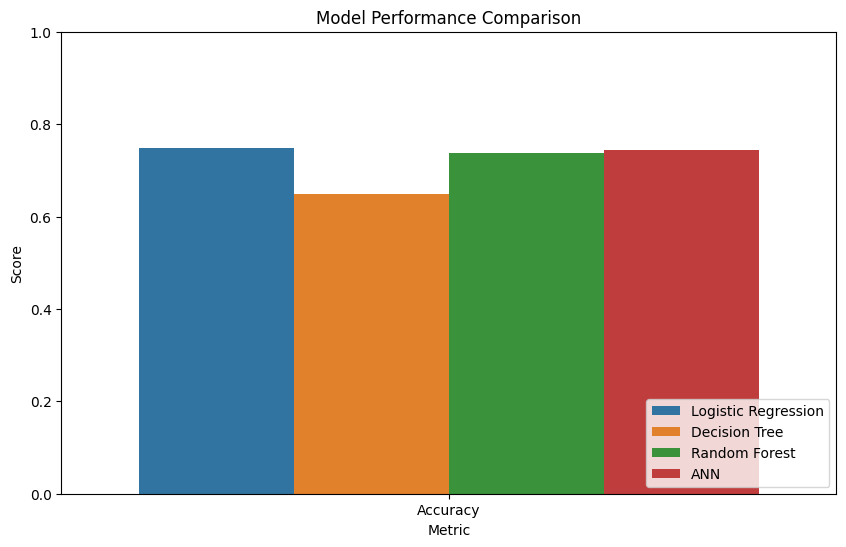

In [46]:

results = [
    {'Model': 'Logistic Regression', 'Accuracy': acc_lr},
    {'Model': 'Decision Tree', 'Accuracy': acc_dt},
    {'Model': 'Random Forest', 'Accuracy': acc_rf},
    {'Model': 'ANN', 'Accuracy': acc_ann}
]

df_results = pd.DataFrame(results)
print(df_results)


df_melt = df_results.melt(id_vars='Model', var_name='Metric', value_name='Score')

plt.figure(figsize=(10,6))
sns.barplot(data=df_melt, x='Metric', y='Score', hue='Model')
plt.title('Model Performance Comparison')
plt.ylim(0,1)
plt.legend(loc='lower right')
plt.show()


In [47]:
best_model = df_results.loc[df_results['Accuracy'].idxmax()]
print("\nBest Model:")
print(best_model)


Best Model:
Model       Logistic Regression
Accuracy               0.748426
Name: 0, dtype: object
